## TP : Open Data Profiling, Data Quality Analysis, Transformations, Modeling and Medallion Architecture

# Tolomey BOGNINOU

## Configuration de l'environnement & Imports  chargement Bronze

In [2]:
pip install ydata-profiling

  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mistralai 1.12.2 requires pyyaml<7.0.0,>=6.0.2, but you have pyyaml 6.0.1 which is incompatible.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
sns.set_style('whitegrid')

PATH = {
    'caract': 'caract-2024.csv',
    'lieux': 'lieux-2024.csv',
    'usagers': 'usagers-2024.csv',
    'vehicules': 'vehicules-2024.csv',
}

caract    = pd.read_csv(PATH['caract'],    sep=';', encoding='utf-8', low_memory=False)
lieux     = pd.read_csv(PATH['lieux'],     sep=';', encoding='utf-8', low_memory=False)
usagers   = pd.read_csv(PATH['usagers'],   sep=';', encoding='utf-8', low_memory=False)
vehicules = pd.read_csv(PATH['vehicules'], sep=';', encoding='utf-8', low_memory=False)

for nom, df in [('caracteristiques', caract), ('lieux', lieux), ('usagers', usagers), ('vehicules', vehicules)]:
    print(f"{nom:15s} : {df.shape[0]:>7,} lignes x {df.shape[1]:>2} colonnes")

caracteristiques :  54,402 lignes x 15 colonnes
lieux           :  70,248 lignes x 18 colonnes
usagers         : 125,187 lignes x 16 colonnes
vehicules       :  92,678 lignes x 11 colonnes


### Data loading and overview ( chargement de la couche Bronze)

## Part 1 : Data Profiling and Data Quality Analysis

### A. Dataset Structure

In [11]:
descriptions = {
    'caract': {
        'Num_Acc': "Identifiant unique de l'accident, clé commune aux 4 tables",
        'jour': "Jour du mois de l'accident (1-31)",
        'mois': "Mois de l'accident (1-12)",
        'an': "Année de l'accident",
        'hrmn': "Heure et minute de l'accident (texte HH:MM)",
        'lum': "Conditions d'éclairage",
        'dep': "Code INSEE du département (inclut les DROM-COM)",
        'com': "Code INSEE de la commune",
        'agg': "Localisation : en agglomération (2) ou hors agglomération (1)",
        'int': "Type d'intersection",
        'atm': "Conditions atmosphériques",
        'col': "Type de collision",
        'adr': "Adresse postale, renseignée surtout en agglomération",
        'lat': "Latitude (texte, virgule comme séparateur décimal)",
        'long': "Longitude (texte, virgule comme séparateur décimal)",
    },
    'lieux': {
        'Num_Acc': "Clé vers l'accident", 'catr': "Catégorie de route",
        'voie': "Numéro ou nom de la route", 'v1': "Indice numérique du numéro de route",
        'v2': "Indice alphanumérique de la route", 'circ': "Régime de circulation",
        'nbv': "Nombre total de voies", 'vosp': "Existence d'une voie réservée",
        'prof': "Profil en long de la route", 'pr': "Numéro du point de repérage amont",
        'pr1': "Distance en mètres au PR amont", 'plan': "Tracé en plan",
        'lartpc': "Largeur du terre-plein central (m)", 'larrout': "Largeur de la chaussée (m)",
        'surf': "État de la surface", 'infra': "Aménagement / infrastructure particulière",
        'situ': "Situation de l'accident", 'vma': "Vitesse maximale autorisée (km/h)",
    },
    'vehicules': {
        'Num_Acc': "Clé vers l'accident", 'id_vehicule': "Identifiant unique du véhicule",
        'num_veh': "Identifiant alphanumérique du véhicule", 'senc': "Sens de circulation",
        'catv': "Catégorie du véhicule", 'obs': "Obstacle fixe heurté",
        'obsm': "Obstacle mobile heurté", 'choc': "Point de choc initial",
        'manv': "Manoeuvre principale avant l'accident", 'motor': "Type de motorisation",
        'occutc': "Nombre d'occupants du transport en commun",
    },
    'usagers': {
        'Num_Acc': "Clé vers l'accident", 'id_usager': "Identifiant unique de l'usager",
        'id_vehicule': "Clé vers le véhicule occupé", 'num_veh': "Identifiant alphanumérique du véhicule",
        'place': "Place occupée dans le véhicule", 'catu': "Catégorie d'usager (conducteur/passager/piéton)",
        'grav': "Gravité des blessures", 'sexe': "Sexe de l'usager",
        'an_nais': "Année de naissance", 'trajet': "Motif du déplacement",
        'secu1': "1er équipement de sécurité", 'secu2': "2e équipement de sécurité",
        'secu3': "3e équipement de sécurité", 'locp': "Localisation du piéton",
        'actp': "Action du piéton", 'etatp': "Piéton seul, accompagné ou en groupe",
    },
}

tables = {'caract': caract, 'lieux': lieux, 'usagers': usagers, 'vehicules': vehicules}

for nom, df in tables.items():
    print(f"\n=== Table {nom.upper()} ({df.shape[0]} lignes, {df.shape[1]} colonnes) ===")
    inv = pd.DataFrame({
        'type': df.dtypes.astype(str),
        'valeurs_non_nulles': df.notna().sum(),
        'pct_manquant': (df.isna().mean() * 100).round(2),
    })
    inv['description'] = inv.index.map(descriptions[nom])
    display(inv)


=== Table CARACT (54402 lignes, 15 colonnes) ===


,type,valeurs_non_nulles,pct_manquant,description
Num_Acc,int64,54402,0.00,"Identifiant unique de l'accident, clé commune ..."
jour,int64,54402,0.00,Jour du mois de l'accident (1-31)
mois,int64,54402,0.00,Mois de l'accident (1-12)
an,int64,54402,0.00,Année de l'accident
hrmn,object,54402,0.00,Heure et minute de l'accident (texte HH:MM)
lum,int64,54402,0.00,Conditions d'éclairage
dep,object,54402,0.00,Code INSEE du département (inclut les DROM-COM)
com,object,54402,0.00,Code INSEE de la commune
agg,int64,54402,0.00,Localisation : en agglomération (2) ou hors ag...
int,int64,54402,0.00,Type d'intersection



=== Table LIEUX (70248 lignes, 18 colonnes) ===


,type,valeurs_non_nulles,pct_manquant,description
Num_Acc,int64,70248,0.00,Clé vers l'accident
catr,int64,70248,0.00,Catégorie de route
voie,object,56917,18.98,Numéro ou nom de la route
v1,int64,70248,0.00,Indice numérique du numéro de route
v2,object,5916,91.58,Indice alphanumérique de la route
circ,int64,70248,0.00,Régime de circulation
nbv,object,70248,0.00,Nombre total de voies
vosp,int64,70248,0.00,Existence d'une voie réservée
prof,int64,70248,0.00,Profil en long de la route
pr,object,70248,0.00,Numéro du point de repérage amont



=== Table USAGERS (125187 lignes, 16 colonnes) ===


,type,valeurs_non_nulles,pct_manquant,description
Num_Acc,int64,125187,0.00,Clé vers l'accident
id_usager,object,125187,0.00,Identifiant unique de l'usager
id_vehicule,object,125187,0.00,Clé vers le véhicule occupé
num_veh,object,125187,0.00,Identifiant alphanumérique du véhicule
place,int64,125187,0.00,Place occupée dans le véhicule
catu,int64,125187,0.00,Catégorie d'usager (conducteur/passager/piéton)
grav,int64,125187,0.00,Gravité des blessures
sexe,int64,125187,0.00,Sexe de l'usager
an_nais,float64,122608,2.06,Année de naissance
trajet,int64,125187,0.00,Motif du déplacement



=== Table VEHICULES (92678 lignes, 11 colonnes) ===


,type,valeurs_non_nulles,pct_manquant,description
Num_Acc,int64,92678,0.00,Clé vers l'accident
id_vehicule,object,92678,0.00,Identifiant unique du véhicule
num_veh,object,92678,0.00,Identifiant alphanumérique du véhicule
senc,int64,92678,0.00,Sens de circulation
catv,int64,92678,0.00,Catégorie du véhicule
obs,int64,92678,0.00,Obstacle fixe heurté
obsm,int64,92678,0.00,Obstacle mobile heurté
choc,int64,92678,0.00,Point de choc initial
manv,int64,92678,0.00,Manoeuvre principale avant l'accident
motor,int64,92678,0.00,Type de motorisation


###  partie B : valeurs manquantes et complétude.

    table colonne  pct_manquant
    lieux  lartpc         99.95
vehicules  occutc         98.98
    lieux      v2         91.58
    lieux    voie         18.98
   caract     adr          4.25
  usagers an_nais          2.06


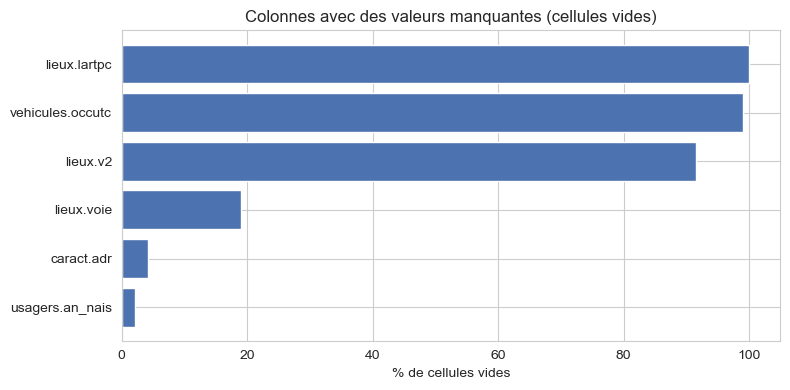

In [12]:
rows = []
for nom, df in tables.items():
    miss = (df.isna().mean() * 100).round(2)
    for col, pct in miss.items():
        rows.append({'table': nom, 'colonne': col, 'pct_manquant': pct})

miss_df = pd.DataFrame(rows).sort_values('pct_manquant', ascending=False)
print(miss_df[miss_df['pct_manquant'] > 0].to_string(index=False))

top = miss_df[miss_df['pct_manquant'] > 0].sort_values('pct_manquant', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(top['table'] + '.' + top['colonne'], top['pct_manquant'], color='#4C72B0')
ax.set_xlabel('% de cellules vides')
ax.set_title('Colonnes avec des valeurs manquantes (cellules vides)')
plt.tight_layout()
plt.show()

####  (les codes -1 "non renseigné")

In [13]:
minus1_cols = {
    'caract': ['atm', 'col'],
    'lieux': ['circ', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'surf', 'infra', 'situ'],
    'usagers': ['trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp'],
    'vehicules': ['senc', 'obs', 'obsm', 'choc', 'manv', 'motor'],
}

for nom, cols in minus1_cols.items():
    df = tables[nom]
    print(f"--- {nom} ---")
    for c in cols:
        pct = (pd.to_numeric(df[c], errors='coerce') == -1).mean() * 100
        if pct > 0:
            print(f"  {c:10s} : {pct:5.2f}% de codes -1 (non renseigne)")

--- caract ---
  col        :  0.01% de codes -1 (non renseigne)
--- lieux ---
  circ       :  6.20% de codes -1 (non renseigne)
  vosp       :  5.45% de codes -1 (non renseigne)
  prof       :  0.07% de codes -1 (non renseigne)
  pr         : 38.95% de codes -1 (non renseigne)
  pr1        : 39.05% de codes -1 (non renseigne)
  plan       :  0.06% de codes -1 (non renseigne)
  surf       :  0.05% de codes -1 (non renseigne)
  infra      :  1.16% de codes -1 (non renseigne)
  situ       :  0.05% de codes -1 (non renseigne)
--- usagers ---
  trajet     :  2.10% de codes -1 (non renseigne)
  secu1      :  1.68% de codes -1 (non renseigne)
  secu2      : 42.99% de codes -1 (non renseigne)
  secu3      : 90.37% de codes -1 (non renseigne)
  locp       : 49.34% de codes -1 (non renseigne)
  actp       : 49.31% de codes -1 (non renseigne)
  etatp      : 91.81% de codes -1 (non renseigne)
--- vehicules ---
  senc       :  0.07% de codes -1 (non renseigne)
  obs        :  0.03% de codes -1 (no

### vérifiions si les gros pourcentages sont un vrai problème ou juste structurels

In [14]:
# adr vs agg
print("Taux de adr manquant selon agg (1=hors agglo, 2=en agglo) :")
print(caract.groupby('agg')['adr'].apply(lambda s: s.isna().mean() * 100).round(2))
print()

# locp/actp/etatp vs catu
pieton = usagers[usagers['catu'] == 3]
non_pieton = usagers[usagers['catu'] != 3]
print("Taux de code -1 pour locp/actp/etatp :")
for c in ['locp', 'actp', 'etatp']:
    p_pieton = (pd.to_numeric(pieton[c], errors='coerce') == -1).mean() * 100
    p_non = (pd.to_numeric(non_pieton[c], errors='coerce') == -1).mean() * 100
    print(f"  {c:6s} : {p_pieton:5.2f}% chez les pietons  vs  {p_non:5.2f}% chez les non-pietons")
print()

# secu2/secu3
s1 = pd.to_numeric(usagers['secu1'], errors='coerce')
s2 = pd.to_numeric(usagers['secu2'], errors='coerce')
n_1equip = ((s1 != -1) & (s2 == -1)).sum()
print(f"Usagers avec secu1 renseigne mais secu2 = -1 (un seul equipement porte, cas normal) : {n_1equip}")

Taux de adr manquant selon agg (1=hors agglo, 2=en agglo) :
agg
1    6.37
2    2.97
Name: adr, dtype: float64

Taux de code -1 pour locp/actp/etatp :
  locp   :  0.02% chez les pietons  vs  53.35% chez les non-pietons
  actp   :  0.02% chez les pietons  vs  53.31% chez les non-pietons
  etatp  :  0.02% chez les pietons  vs  99.26% chez les non-pietons

Usagers avec secu1 renseigne mais secu2 = -1 (un seul equipement porte, cas normal) : 51921


#### Missingness critique

La plupart des gros pourcentages ne sont pas des problèmes de qualité, juste des champs qui ne
s'appliquent pas à toutes les lignes. lartpc (99.95%), occutc (98.98%) et v2 (91.58%) concernent
des cas particuliers (terre-plein central, transport en commun). Pareil pour secu2/secu3, locp,
actp et etatp : ces champs ne concernent que les piétons ou les usagers portant plusieurs
équipements, et la vérification par sous-population le confirme bien puisque locp/actp/etatp
tombent à 0.02% de non-renseigné chez les piétons contre 53 à 99% chez les autres usagers, pour
qui la question ne se pose pas.

Les deux vraies pertes d'information sont adr et an_nais. adr reste manquant sur 2.97% des
accidents en agglomération, alors que le champ est censé y être systématiquement rempli. Mais
c'est surtout an_nais qui pose problème : 2.06% de manquant (~2580 usagers), et c'est la variable
qui sert à calculer l'âge, utilisée dans presque toutes les analyses démographiques du modèle Gold.

#### Remédiation

Pour lartpc, occutc, v2, secu2/secu3, locp/actp/etatp et pr/pr1, pas d'imputation : on les recode
en "Non applicable" dans le Silver plutôt que de les traiter comme un vrai manque.

Pour adr et voie, on garde "Non renseigné" tel quel, la géolocalisation lat/long (complète à 100%)
suffit de toute façon à situer l'accident.

Pour an_nais, pas question d'imputer par une moyenne, ça fausserait la distribution des âges. On
exclut plutôt ces ~2580 lignes des analyses par âge, avec un flag dédié pour rester transparent.

### C. Consistency and Validity Checks 

###  (plages de valeurs : coordonnées, âges, vitesse)

In [ ]:
#  coordonnees 
lat = pd.to_numeric(caract['lat'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
lon = pd.to_numeric(caract['long'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
print("lat:", lat.min(), lat.max(), "| lon:", lon.min(), lon.max())
metro = lat.between(41, 51.5) & lon.between(-5.5, 9.7)
print("coords en metropole:", metro.sum(), "/ hors metropole (DOM-TOM):", (~metro).sum())
print(caract.loc[~metro, 'dep'].value_counts().head(12))
print()

#  ages 
age = 2024 - usagers['an_nais']
print("age min/max/moyenne:", age.min(), age.max(), round(age.mean(), 1))
print("ages negatifs:", (age < 0).sum(), "| ages > 110:", (age > 110).sum())
print()

# vma
vma = pd.to_numeric(lieux['vma'], errors='coerce')
print("vma == -1 (non renseigne):", (vma == -1).sum())
print("vma > 130 km/h (anomalies):", (vma > 130).sum(), sorted(vma[vma > 130].unique()))

lat: -22.433239 51.07874 | lon: -178.094387 167.863219
coords en metropole: 51055 / hors metropole (DOM-TOM): 3347
dep
974    934
973    631
971    616
972    551
987    270
988    156
976    119
978     37
977     22
986      6
2B       3
975      2
Name: count, dtype: int64

age min/max/moyenne: 0.0 110.0 38.9
ages negatifs: 0 | ages > 110: 0

vma == -1 (non renseigne): 3630
vma > 130 km/h (anomalies): 29 [140, 300, 301, 500, 700, 800, 900]


 ### (catégories invalides)

In [17]:
print("sexe value_counts:", usagers['sexe'].value_counts().to_dict())
sub = usagers[usagers['sexe'] == -1]
print("sexe=-1 :", len(sub), "lignes | catu:", sub['catu'].value_counts().to_dict(),
      "| an_nais manquant:", sub['an_nais'].isna().sum(), "| grav:", sub['grav'].value_counts().to_dict())
print()
print("catv=-1 (code absent du guide de codification):")
print(vehicules[vehicules['catv'] == -1][['Num_Acc', 'id_vehicule', 'catv']])

sexe value_counts: {1: 83864, 2: 38928, -1: 2395}
sexe=-1 : 2395 lignes | catu: {1: 2389, 3: 3, 2: 3} | an_nais manquant: 2390 | grav: {1: 2395}

catv=-1 (code absent du guide de codification):
            Num_Acc  id_vehicule  catv
84280  202400049415  155 694 739    -1


###  (doublons + intégrité référentielle)

In [16]:
print("doublons stricts (lignes 100% identiques):")
for nom, df in tables.items():
    print(f"  {nom}: {df.duplicated().sum()}")
print()
print("lieux : nb Num_Acc avec plus d'une ligne lieux :",
      (lieux['Num_Acc'].value_counts() > 1).sum(), "/", lieux['Num_Acc'].nunique(), "accidents")
print()

print("Num_Acc orphelins (present dans une table mais absent de caract) :")
print("  lieux:", (~lieux.Num_Acc.isin(caract.Num_Acc)).sum())
print("  usagers:", (~usagers.Num_Acc.isin(caract.Num_Acc)).sum())
print("  vehicules:", (~vehicules.Num_Acc.isin(caract.Num_Acc)).sum())
print()

veh_ids = vehicules['id_vehicule'].astype(str).str.strip()
usa_ids = usagers['id_vehicule'].astype(str).str.strip()
fuite = veh_ids[~veh_ids.isin(usa_ids)]
print("vehicules sans aucun usager rattache (conducteurs en fuite non crees) :", fuite.nunique())

doublons stricts (lignes 100% identiques):
  caract: 0
  lieux: 2
  usagers: 0
  vehicules: 0

lieux : nb Num_Acc avec plus d'une ligne lieux : 15645 / 54402 accidents

Num_Acc orphelins (present dans une table mais absent de caract) :
  lieux: 0
  usagers: 0
  vehicules: 0

vehicules sans aucun usager rattache (conducteurs en fuite non crees) : 24


#### Coherence et validite : ce qu'on retient

Les coordonnees et les ages sont propres : aucune valeur aberrante. Les points hors du rectangle
metropolitain ne sont pas des erreurs, ce sont les DOM-TOM (974 Reunion, 973 Guyane, 971 Guadeloupe,
972 Martinique, 987 Polynesie, 988 Nouvelle-Caledonie, etc.), 3347 accidents au total.

Deux vraies anomalies de categorie : sexe contient 2395 lignes a -1, alors que le guide de codification
ne prevoit que 1 (masculin) et 2 (feminin). Ce n'est pas du hasard : ces lignes sont a 99.8% des
conducteurs (catu=1) avec l'annee de naissance manquante aussi, ce qui correspond exactement aux
"usagers en fuite" mentionnes dans la doc, dont le sexe et l'age ne sont pas connus. catv a le meme
souci sur une seule ligne, negligeable. Cote vma, 29 lignes annoncent des vitesses limites de 140 a
900 km/h, ce qui n'existe pas sur le reseau routier francais, donc clairement des erreurs de saisie.

Cote doublons, caract, usagers et vehicules sont clean (0 doublon). lieux a 2 lignes strictement
identiques, mais surtout un probleme plus structurel : 15645 accidents sur 54402 (29%) ont plusieurs
lignes lieux alors que la doc precise que ce fichier decrit "le lieu principal" de l'accident, donc une
seule ligne attendue par accident. Ca casse la cardinalite 1-1 attendue entre caract et lieux.

Enfin, l'integrite referentielle entre les 4 tables est parfaite (aucun Num_Acc orphelin), et le nombre
de vehicules sans usager rattache (24) correspond exactement au chiffre donne par la doc ONISR pour les
conducteurs en fuite non crees en base en 2024. Ca confirme que l'extraction est fiable et que cette
"anomalie" est en fait un phenomene documente, pas une erreur d'extraction.

### Partie D, synthèse qualité

### D. Synthese qualite des donnees

| Probleme                                    | Ampleur                        | Type                    |
|----------------------------------------------|---------------------------------|--------------------------|
| an_nais manquant                              | 2.06% des usagers (~2580)      | Manque reel              |
| adr manquant en agglomeration                 | 2.97% des accidents en agglo   | Manque reel (mineur)     |
| sexe = -1 (hors codification)                 | 2395 usagers                   | Anomalie categorielle    |
| catv = -1 (hors codification)                 | 1 vehicule                     | Anomalie categorielle    |
| vma > 130 km/h                                | 29 lignes (jusqu'a 900 km/h)   | Anomalie de valeur       |
| lieux : lignes strictement dupliquees         | 2 lignes                       | Doublon                  |
| lieux : plusieurs lignes pour un meme accident| 15645 accidents / 54402 (29%)  | Violation de cardinalite |

Le reste des colonnes tres incompletes (lartpc, occutc, v2, secu2/secu3, locp/actp/etatp, pr/pr1)
n'est pas un probleme de qualite a proprement parler, juste des champs qui ne s'appliquent qu'a une
partie des lignes (voir partie B).

#### Impact sur l'analyse en aval

Le probleme le plus dangereux pour la suite, c'est la duplication dans lieux. Si on joint caract et
lieux directement sur Num_Acc pour construire une table plat ou le modele Gold, les 15645 accidents
concernes se retrouvent comptes 2, 3 voire 4 fois (le cas le plus extreme observe, 202400050330, a 5
lignes lieux). N'importe quel indicateur agrege par la suite (nombre d'accidents, nombre de tues, taux
de gravite par departement) serait alors surestime, sans que ca se voie a premiere vue puisque les
chiffres restent plausibles. C'est typiquement le genre d'erreur silencieuse qui passe inapercue si on
ne verifie pas les cardinalites avant de joindre les tables. Il faut donc deduplication lieux a une
ligne par accident avant toute jointure vers le fait Gold.

Les anomalies sur sexe et vma sont moins graves en volume mais faussent des moyennes si on ne les
filtre pas : une vitesse limite de 900 km/h dans un calcul de moyenne suffit a decaler completement le
resultat. Le cas sexe=-1 doit lui etre garde comme categorie "Inconnu / usager en fuite" plutot que
supprime, sinon on sous-estime le nombre de delits de fuite dans les stats de securite routiere, ce qui
serait justement contraire a l'usage attendu de ce dataset.

an_nais manquant impacte surtout les KPIs par age (age moyen par gravite, pyramide des ages des
victimes), qui devront exclure ces lignes explicitement plutot que d'imputer une valeur inventee.

## Partie 2 Transformations, Modeling and Medallion Architecture 

### A- transformations Silver

### standardisation caract

In [18]:
log = []
def logit(table, transformation, detail):
    log.append({'table': table, 'transformation': transformation, 'detail': detail})

silver_caract = caract.copy()
silver_caract['date'] = pd.to_datetime(dict(year=silver_caract['an'], month=silver_caract['mois'], day=silver_caract['jour']), errors='coerce')
silver_caract['heure'] = silver_caract['hrmn'].str.split(':').str[0].astype(int)
silver_caract['lat'] = pd.to_numeric(silver_caract['lat'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
silver_caract['long'] = pd.to_numeric(silver_caract['long'].astype(str).str.replace(',', '.', regex=False), errors='coerce')
logit('caract', 'Standardisation', 'jour/mois/an -> date (datetime) ; hrmn -> heure (int) ; lat/long texte virgule -> float')

def cat_moment(h):
    if 0 <= h < 6: return 'Nuit'
    if 6 <= h < 12: return 'Matin'
    if 12 <= h < 18: return 'Apres-midi'
    return 'Soir'

silver_caract['moment_journee'] = silver_caract['heure'].apply(cat_moment)
silver_caract['jour_semaine'] = silver_caract['date'].dt.day_name()
silver_caract['weekend'] = silver_caract['date'].dt.dayofweek >= 5
logit('caract', 'Enrichissement', 'moment_journee, jour_semaine, weekend derives de la date/heure')

print("dates invalides:", silver_caract['date'].isna().sum())
print(silver_caract[['Num_Acc','date','heure','moment_journee','jour_semaine','weekend']].head())

dates invalides: 0
        Num_Acc       date  heure moment_journee jour_semaine  weekend
0  202400000001 2024-03-25      7          Matin       Monday    False
1  202400000002 2024-03-20     15     Apres-midi    Wednesday    False
2  202400000003 2024-03-22     19           Soir       Friday    False
3  202400000004 2024-03-24     17     Apres-midi       Sunday     True
4  202400000005 2024-03-25     19           Soir       Monday    False


### CLEANING - lieux : dédoublonnage + nettoyage

In [19]:
n0 = len(lieux)
silver_lieux = lieux.drop_duplicates().copy()
n1 = len(silver_lieux)
logit('lieux', 'Dedoublonnage', f'{n0 - n1} lignes strictement dupliquees supprimees')

silver_lieux = silver_lieux.drop_duplicates(subset='Num_Acc', keep='first').copy()
n2 = len(silver_lieux)
logit('lieux', 'Dedoublonnage', f'{n1 - n2} lignes excedentaires supprimees pour ramener a 1 ligne par accident')

for c in ['nbv', 'larrout', 'lartpc', 'pr', 'pr1']:
    silver_lieux[c] = pd.to_numeric(silver_lieux[c].astype(str).str.replace(',', '.', regex=False), errors='coerce')
    silver_lieux.loc[silver_lieux[c] == -1, c] = np.nan
logit('lieux', 'Standardisation', 'nbv/larrout/lartpc/pr/pr1 convertis en numerique, codes -1 -> NaN')

vma_num = pd.to_numeric(silver_lieux['vma'], errors='coerce')
silver_lieux['vma_valide'] = ~((vma_num == -1) | (vma_num > 130))
n_vma_corr = (~silver_lieux['vma_valide']).sum()
silver_lieux['vma'] = vma_num.where(silver_lieux['vma_valide'], np.nan)
logit('lieux', 'Nettoyage', f'vma : {n_vma_corr} valeurs invalides mises a NaN, flag vma_valide ajoute')

print("lieux avant:", n0, "-> silver_lieux apres:", len(silver_lieux))
print("verification 1 ligne par accident :", silver_lieux['Num_Acc'].nunique() == len(silver_lieux))

lieux avant: 70248 -> silver_lieux apres: 54402
verification 1 ligne par accident : True


### vehicules + usagers

In [20]:
silver_vehicules = vehicules.drop_duplicates().copy()
n_catv = (silver_vehicules['catv'] == -1).sum()
silver_vehicules.loc[silver_vehicules['catv'] == -1, 'catv'] = np.nan
logit('vehicules', 'Nettoyage', f'catv : {n_catv} code(s) -1 hors codification mis a NaN')

silver_usagers = usagers.drop_duplicates().copy()
silver_usagers['id_usager'] = silver_usagers['id_usager'].astype(str).str.strip()
silver_usagers['id_vehicule'] = silver_usagers['id_vehicule'].astype(str).str.strip()
logit('usagers', 'Standardisation', 'id_usager / id_vehicule : espaces internes supprimes')

silver_usagers['age'] = 2024 - silver_usagers['an_nais']
silver_usagers['usager_en_fuite'] = (silver_usagers['sexe'] == -1)
n_fuite = silver_usagers['usager_en_fuite'].sum()
logit('usagers', 'Enrichissement', f'age calcule depuis an_nais ; flag usager_en_fuite ajoute ({n_fuite} usagers)')

print("silver_vehicules:", silver_vehicules.shape, "| silver_usagers:", silver_usagers.shape)

silver_vehicules: (92678, 11) | silver_usagers: (125187, 18)


### enrichissement : indice de gravité

In [21]:
poids_gravite = {1: 0, 2: 4, 3: 2, 4: 1}
silver_usagers['poids_gravite'] = silver_usagers['grav'].map(poids_gravite)

accident_gravite = silver_usagers.groupby('Num_Acc').agg(
    nb_usagers=('id_usager', 'count'),
    nb_tues=('grav', lambda s: (s == 2).sum()),
    nb_hospitalises=('grav', lambda s: (s == 3).sum()),
    nb_blesses_legers=('grav', lambda s: (s == 4).sum()),
    nb_indemnes=('grav', lambda s: (s == 1).sum()),
    indice_gravite=('poids_gravite', 'sum'),
).reset_index()

accident_gravite['classe_gravite'] = np.select(
    [accident_gravite['nb_tues'] > 0, accident_gravite['nb_hospitalises'] > 0],
    ['Mortel', 'Grave'], default='Leger'
)
logit('usagers -> accident', 'Enrichissement', 'indice_gravite et classe_gravite (Mortel/Grave/Leger) calcules par accident')

nb_vehicules_acc = silver_vehicules.groupby('Num_Acc').size().rename('nb_vehicules').reset_index()
logit('vehicules -> accident', 'Enrichissement', 'nb_vehicules calcule par accident')

print(accident_gravite['classe_gravite'].value_counts())
print()
print(accident_gravite.head())

classe_gravite
Leger     34744
Grave     16432
Mortel     3226
Name: count, dtype: int64

        Num_Acc  nb_usagers  nb_tues  nb_hospitalises  nb_blesses_legers  nb_indemnes  indice_gravite classe_gravite
0  202400000001           2        0                1                  0            1               2          Grave
1  202400000002           2        0                1                  0            1               2          Grave
2  202400000003           5        0                1                  3            1               5          Grave
3  202400000004           1        0                0                  1            0               1          Leger
4  202400000005           4        0                0                  3            1               3          Leger


### log de documentation

In [23]:
log_df = pd.DataFrame(log)
display(log_df)

,table,transformation,detail
0,caract,Standardisation,jour/mois/an -> date (datetime) ; hrmn -> heur...
1,caract,Enrichissement,"moment_journee, jour_semaine, weekend derives ..."
2,lieux,Dedoublonnage,2 lignes strictement dupliquees supprimees
3,lieux,Dedoublonnage,15844 lignes excedentaires supprimees pour ram...
4,lieux,Standardisation,nbv/larrout/lartpc/pr/pr1 convertis en numeriq...
5,lieux,Nettoyage,"vma : 1587 valeurs invalides mises a NaN, flag..."
6,vehicules,Nettoyage,catv : 1 code(s) -1 hors codification mis a NaN
7,usagers,Standardisation,id_usager / id_vehicule : espaces internes sup...
8,usagers,Enrichissement,age calcule depuis an_nais ; flag usager_en_fu...
9,usagers -> accident,Enrichissement,indice_gravite et classe_gravite (Mortel/Grave...


### B- modélisation Gold

### (les 4 dimensions)

In [24]:
# --- DIM_DATE ---
dim_date = silver_caract[['date','jour','mois','an','jour_semaine','weekend']].drop_duplicates(subset='date').copy()
dim_date['date_id'] = range(1, len(dim_date) + 1)
dim_date = dim_date[['date_id','date','jour','mois','an','jour_semaine','weekend']]

# --- DIM_LOCALISATION (grain commune) ---
dim_loc = caract[['dep','com']].drop_duplicates().reset_index(drop=True).copy()
dim_loc['loc_id'] = range(1, len(dim_loc) + 1)
dim_loc = dim_loc[['loc_id','dep','com']]

# --- DIM_CONDITIONS (meteo + route + collision) ---
cond_cols_caract = ['lum','atm','col','int','agg']
cond_cols_lieux = ['circ','surf','plan','prof','catr']
cond_src = caract[['Num_Acc'] + cond_cols_caract].merge(
    silver_lieux[['Num_Acc'] + cond_cols_lieux], on='Num_Acc')
combo = cond_src[cond_cols_caract + cond_cols_lieux].drop_duplicates().reset_index(drop=True).copy()
combo['cond_id'] = range(1, len(combo) + 1)
dim_conditions = combo[['cond_id'] + cond_cols_caract + cond_cols_lieux]

# --- DIM_TYPE_VEHICULE ---
label_catv = {
    0:"Indeterminable",1:"Bicyclette",2:"Cyclomoteur <50cm3",3:"Voiturette",7:"VL seul",
    10:"VU seul",13:"PL seul 3.5-7.5T",14:"PL seul >7.5T",15:"PL >3.5T + remorque",
    16:"Tracteur routier seul",17:"Tracteur routier + semi-remorque",20:"Engin special",
    21:"Tracteur agricole",30:"Scooter <50cm3",31:"Motocyclette 50-125cm3",
    32:"Scooter 50-125cm3",33:"Motocyclette >125cm3",34:"Scooter >125cm3",
    35:"Quad leger",36:"Quad lourd",37:"Autobus",38:"Autocar",39:"Train",40:"Tramway",
    41:"3 roues motorisees <=50cm3",42:"3 roues motorisees 50-125cm3",43:"3 roues motorisees >125cm3",
    50:"EDP a moteur (trottinette elec...)",60:"EDP sans moteur",80:"Velo a assistance electrique",
    99:"Autre vehicule"
}
dim_vehicule = pd.DataFrame({'catv': sorted(vehicules['catv'].unique())})
dim_vehicule = dim_vehicule[dim_vehicule['catv'] != -1]
dim_vehicule['libelle_categorie'] = dim_vehicule['catv'].map(label_catv)
dim_vehicule = dim_vehicule.reset_index(drop=True)

for nom, d in [('DIM_DATE',dim_date), ('DIM_LOCALISATION',dim_loc), ('DIM_CONDITIONS',dim_conditions), ('DIM_TYPE_VEHICULE',dim_vehicule)]:
    print(f"{nom}: {d.shape}")

DIM_DATE: (366, 7)
DIM_LOCALISATION: (11285, 3)
DIM_CONDITIONS: (13673, 11)
DIM_TYPE_VEHICULE: (31, 2)


### FACT_ACCIDENTS

In [25]:
fact = silver_caract[['Num_Acc','date','dep','com','lat','long','moment_journee']].copy()
fact = fact.merge(dim_date[['date_id','date']], on='date', how='left')
fact = fact.merge(dim_loc, on=['dep','com'], how='left')
fact = fact.merge(cond_src, on='Num_Acc', how='left').merge(
    dim_conditions, on=cond_cols_caract + cond_cols_lieux, how='left')
fact = fact.merge(accident_gravite, on='Num_Acc', how='left')
fact = fact.merge(nb_vehicules_acc, on='Num_Acc', how='left')
fact = fact.merge(silver_lieux[['Num_Acc','vma']], on='Num_Acc', how='left')

fact_accidents = fact[['Num_Acc','date_id','loc_id','cond_id','lat','long','moment_journee',
                        'vma','nb_usagers','nb_vehicules','nb_tues','nb_hospitalises',
                        'nb_blesses_legers','nb_indemnes','indice_gravite','classe_gravite']]

print("FACT_ACCIDENTS:", fact_accidents.shape)
print("aucune ligne perdue:", len(fact_accidents) == caract['Num_Acc'].nunique())
print("aucun FK manquant:", fact_accidents[['date_id','loc_id','cond_id']].isna().sum().to_dict())
print(fact_accidents.head())

FACT_ACCIDENTS: (54402, 16)
aucune ligne perdue: True
aucun FK manquant: {'date_id': 0, 'loc_id': 0, 'cond_id': 0}
        Num_Acc  date_id  loc_id  cond_id        lat      long moment_journee   vma  nb_usagers  nb_vehicules  nb_tues  nb_hospitalises  \
0  202400000001        1       1        1  47.562770  6.758320          Matin  90.0           2             2        0                1   
1  202400000002        2       2        2  47.021090  4.837550     Apres-midi  30.0           2             1        0                1   
2  202400000003        3       3        3  44.902384  2.496418           Soir  50.0           5             1        0                1   
3  202400000004        4       4        4  49.191660 -0.398510     Apres-midi  50.0           1             2        0                0   
4  202400000005        1       5        5  43.390000  5.350000           Soir  50.0           4             4        0                0   

   nb_blesses_legers  nb_indemnes  indice_gravite 

###  Code (FACT_VEHICULE_IMPLIQUE, la table bridge)

In [26]:
fact_vehicule = silver_vehicules[['Num_Acc','id_vehicule','catv','obs','obsm','choc','manv']].merge(
    dim_vehicule[['catv']], on='catv', how='left')

print("FACT_VEHICULE_IMPLIQUE:", fact_vehicule.shape)
print(fact_vehicule.head())

FACT_VEHICULE_IMPLIQUE: (92678, 7)
        Num_Acc  id_vehicule  catv  obs  obsm  choc  manv
0  202400000001  155 781 758   7.0    0     2     1    13
1  202400000001  155 781 759  14.0    0     2     2    21
2  202400000002  155 781 757  10.0    0     1     3    15
3  202400000003  155 781 756   3.0    9     1     1     1
4  202400000004  155 781 754  34.0    0     2     0     0
